<a href="https://colab.research.google.com/github/abdlehroub/Heart-failer-Detection-ML-Project/blob/main/Copy_of_ML_First_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Failure Clinical Record**

**Name: Abdelrahman Imhimid**  
**ID: 1230219**

##**Introduction**



In this project, we analyze a dataset from clinical records of heart failure. We apply the fundamental concepts of Exploratory Data Analysis (EDA) and implement machine learning models for regression and classification. The performance of these models is then evaluated using standard metrics such as RMSE and MAE for regression, and Precision and Recall for classification.

##**Abstract**



This project analyzes a heart failure dataset using regression and classification models. Exploratory Data analysis examines the weak correlations between most features, identifying which models perform best in linear regression when predicting age. For classification, Logistic Regression and kNN were compared to predict DEATH_Event. The results showed that Logistic Regression performed better, with lower error, higher accuracy and recall, beacuse the dataset lacks specific clustering patterns, which weakens the effectiveness of kNN. Therefore, this study should highlight how data characteristics affect model performance.

##**Road Map**



1. Check if the data need any pre-processing using the concepts of EDA, and do it.
2. Print a summary statistics for all attributes in the dataset.
3. Create some visualisations for the dataset attributes.
4. Visualize the correaltion betwen some dependent and independent attributes.
5. Split the data to 80% training and 20% testing and from the correlation coefficient select one attribute to predict the age using Linear Regression.
6. Predict the value of the age with the indepenent attributes, using Linear Regrission.
7. Using the performance measures, compare the previuos Linear Regression models.
8. Predict the death event using Logistic Regression and KNN and compare the results using performance measures.

##**Import The Libraries**

In [ ]:
!pip install matplotlib-venn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,mean_absolute_error , r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, auc, roc_curve, roc_auc_score
from google.colab import drive



##**Import the Dataset:**
Import the dataset [UCL Heart Failure Clinical Records
](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from drive:

In [ ]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/heart_failure_clinical_records_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


##**Data Info**
Show the columns and its types:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


The result shows that there are 13 columns, there are categorical columns but they are converted to 0-1 so we dont need to encode them.

##**Missing Values**
Check if there are missing values in the data:

In [ ]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


There is no missing value in the dataset.

##**Duplications**
Check if there are duplicated values:

In [ ]:
print(df.duplicated().sum())

0


There is no duplicated values in the data set.

##**Summary Statistics**
To describe the data and the distribution:



In [ ]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


From the table above we can conclude the following:  
**1. Age:**  
   From the measures, we can conclude that the overall ages is slightly above the mid point (mean = 60.83, median = 60.00), indicating that most patients are around 60 years old.  
**2. Anaemia:**  
The values are binary (0,1) so the maen shows the percent of ones in the data, so we can say that 43.1% of the patients have anaemia.  
**3. Creatinine Phosphokinase:**  
There is a clear difference between the mean and the median, which indicates that the data is skewed to the right because the mean is greater than the median. In addition, the high standard deviation means that the data have high variability.  
**4.Diabetes:**  
   The values are binary and mean = 0.418, which indicates that 41.8% of the patients are have diabetes.  
**5. Ejection Fraction:**  
  From the measures, we can conclude that the overall ejection fraction is slightly above the mid point (mean = 38.08, meadian = 38.00), which indicates that most patients have close to 38.00 ejection fraction.  
  **6. High Blood Pressure:**  
  The values are binary, so 38.08% of the patients have high blood pressure.  
  **7. Platelets:**  
  The difference between mean and median is really low, so the distribution is not significantly skewed, that means on average, most patients have around 263.36 kiloplatelets/mL in their blood.  
  **8. Serum Creatinine:**
  There is difference between mean and median, this means that the data is skewed, also the max value looks like outlier. In Addition, high standard deviation indicates that the data have high variability.  
  **9. Serum Sodium:**
   From the measures, we can conclude that the overall patients have slightly above quantity of Serum Sodium in their bloods from the mid point (mean = 136.63, median = 137.00), and standard deviation is realy low comparing with the other measures, so the distribution is not significantly skewed.  
   **10. Sex:**
   The values are binary (0,1) so the maen shows the percent of ones in the data, so we can say that 64.8% of the patients are males (since males are have 1 value).
  **11. Smoking:**  
   The values are binary (0,1) so the maen shows the percent of ones in the data, so we can say that 32.1% of the patients are smokers.  
   **12. Time**:
This feature related to follow up time, and it has a little skweens and high standard deviation, so there is variation on how every patient got time.  
**13. Death Event**:
This is a binary feature clarify who are paitens died, mean shows that 32.1% of patients are died.


##**Outliers**
Detect the outliers and handle it if they exist.**bold text**

1. Create Box Plot for the numeric columns:

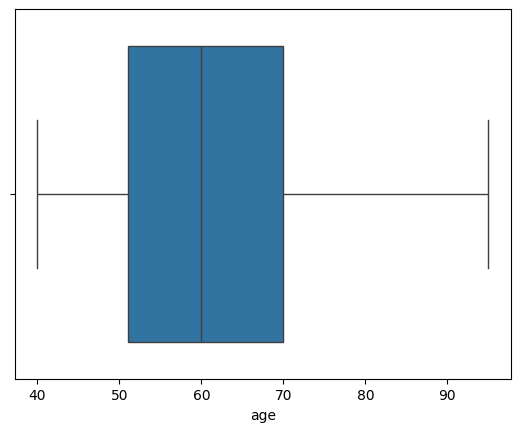

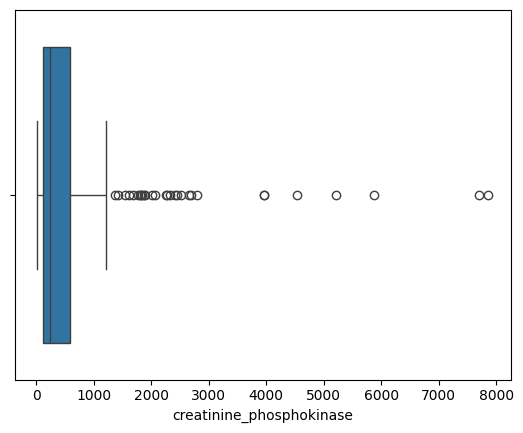

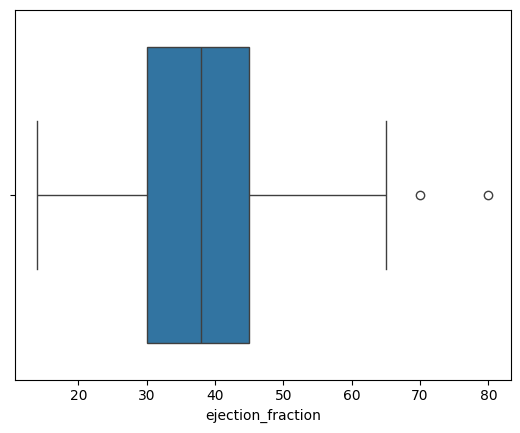

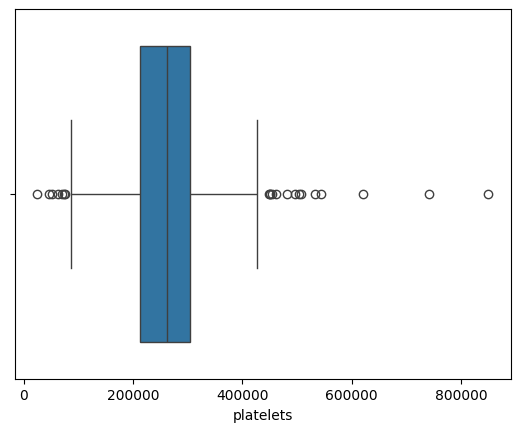

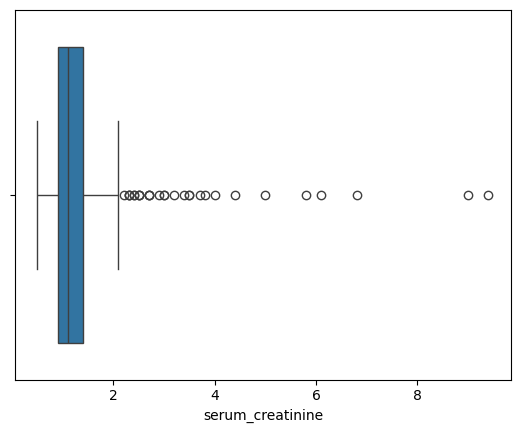

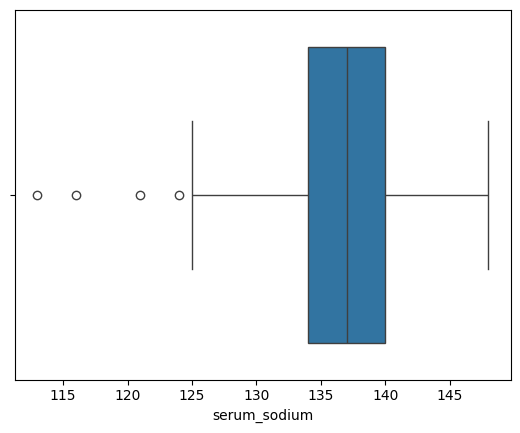

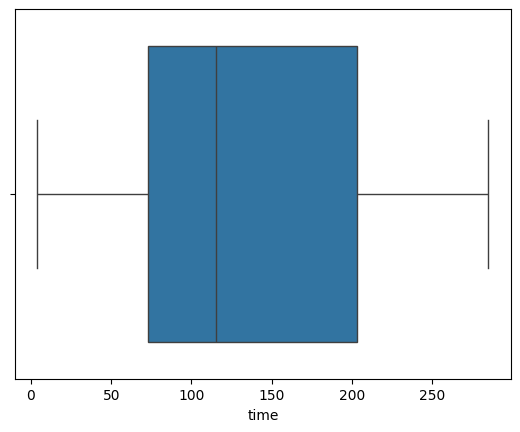

In [ ]:
def box_plot(df, col):
    sns.boxplot(x=df[col])
    plt.show()

categorical_col = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and col not in categorical_col :
        box_plot(df, col)

2. Detect outliers using IQR:

In [ ]:
def detect_iqr(df, col):
  Q1 = np.quantile(df[col], 0.25)
  Q3 = np.quantile(df[col], 0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = []
  for x in df[col]:
    if x < lower_bound or x > upper_bound:
      outliers.append(x)
  return outliers

categorical_col = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and col not in categorical_col :
        outliers = detect_iqr(df, col)
        print(f"Outliers in column {col}: [{len(outliers)}]\n {outliers}\n")

Outliers in column age: [0]
 []

Outliers in column creatinine_phosphokinase: [29]
 [7861, 2656, 1380, 3964, 7702, 5882, 5209, 1876, 1808, 4540, 1548, 1610, 2261, 1846, 2334, 2442, 3966, 1419, 1896, 1767, 2281, 2794, 2017, 2522, 2695, 1688, 1820, 2060, 2413]

Outliers in column ejection_fraction: [2]
 [80, 70]

Outliers in column platelets: [21]
 [454000.0, 47000.0, 451000.0, 461000.0, 497000.0, 621000.0, 850000.0, 507000.0, 448000.0, 75000.0, 70000.0, 73000.0, 481000.0, 504000.0, 62000.0, 533000.0, 25100.0, 451000.0, 51000.0, 543000.0, 742000.0]

Outliers in column serum_creatinine: [29]
 [2.7, 9.4, 4.0, 5.8, 3.0, 3.5, 2.3, 3.0, 4.4, 6.8, 2.2, 2.7, 2.3, 2.9, 2.5, 2.3, 3.2, 3.7, 3.4, 6.1, 2.5, 2.4, 2.5, 3.5, 9.0, 5.0, 2.4, 2.7, 3.8]

Outliers in column serum_sodium: [4]
 [116, 121, 124, 113]

Outliers in column time: [0]
 []



3. Detect Outliers Using Z-Score:

In [ ]:
def detect_zscore(df, col):
  mean = df[col].mean()
  std = df[col].std()
  outliers = []
  for x in df[col]:
    z_score = (x - mean) / std
    if z_score > 3 or z_score < -3:
      outliers.append(x)
  return outliers
categorical_col = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and col not in categorical_col :
        outliers = detect_zscore(df, col)
        print(f"Outliers in column {col}: [{len(outliers)}]\n {outliers}\n")

Outliers in column age: [0]
 []

Outliers in column creatinine_phosphokinase: [7]
 [7861, 3964, 7702, 5882, 5209, 4540, 3966]

Outliers in column ejection_fraction: [1]
 [80]

Outliers in column platelets: [3]
 [621000.0, 850000.0, 742000.0]

Outliers in column serum_creatinine: [6]
 [9.4, 5.8, 6.8, 6.1, 9.0, 5.0]

Outliers in column serum_sodium: [3]
 [116, 121, 113]

Outliers in column time: [0]
 []



But some of this outliers values may occuerd in real world so I will handle it with respect of the medical references to avoid any mistakes:

In [ ]:
limits = {
    "creatinine_phosphokinase": (10, 100000),
    "ejection_fraction": (5, 100),
    "platelets": (5000, 1000000),
    "serum_creatinine": (0.1, 15),
    "serum_sodium": (90, 200)
}
for col in limits:
    lower_limit = limits[col][0]
    upper_limit = limits[col][1]
    invalid_values = df[(df[col]>upper_limit) | (df[col] <lower_limit)][col]
    print(f"# of Invalid values in {col}: {len(invalid_values)}\n")


# of Invalid values in creatinine_phosphokinase: 0

# of Invalid values in ejection_fraction: 0

# of Invalid values in platelets: 0

# of Invalid values in serum_creatinine: 0

# of Invalid values in serum_sodium: 0



There is no invalid values so there is no outlier to delete.

##**Density Plots**


**For Age:**

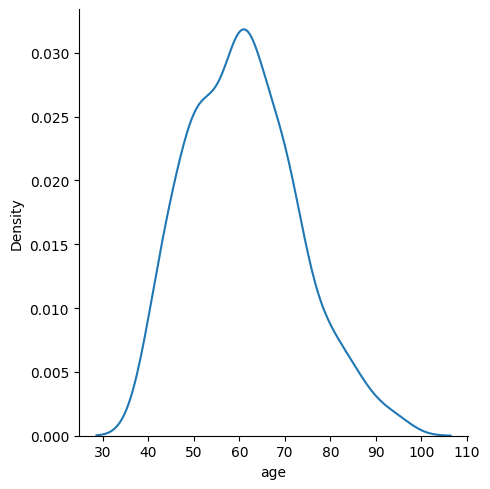

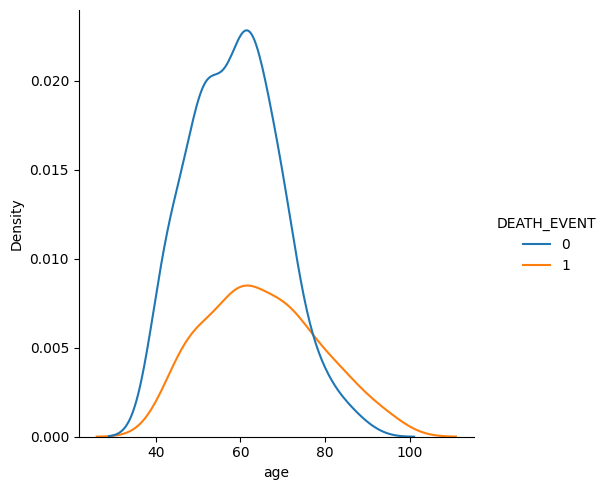

In [ ]:
sns.displot(df, x='age',kind='kde')
sns.displot(df, x='age',kind='kde', hue='DEATH_EVENT')

**For Creatinine Phosphokinase:**

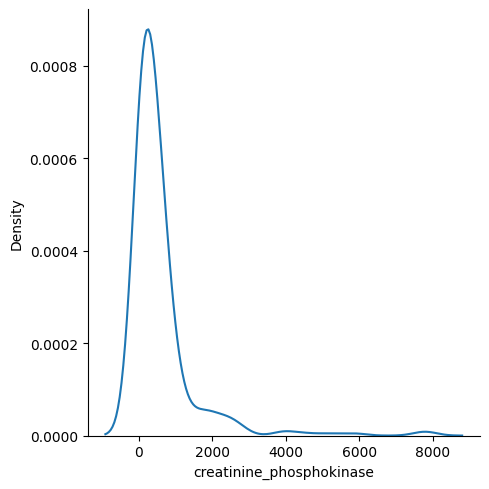

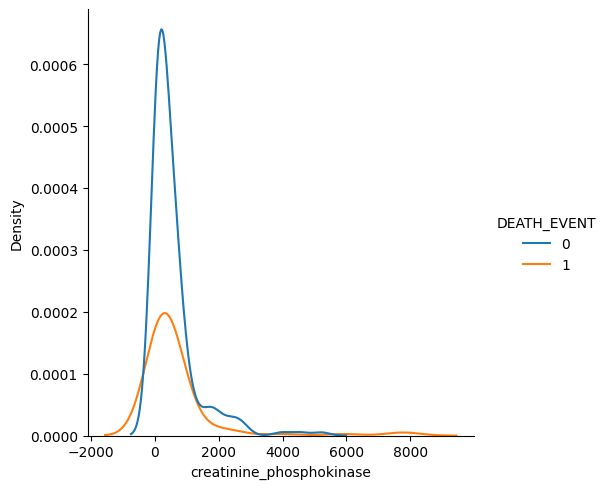

In [ ]:
sns.displot(df, x= 'creatinine_phosphokinase', kind = 'kde')
sns.displot(df, x= 'creatinine_phosphokinase', kind = 'kde', hue = 'DEATH_EVENT')

**For Ejection Fraction**

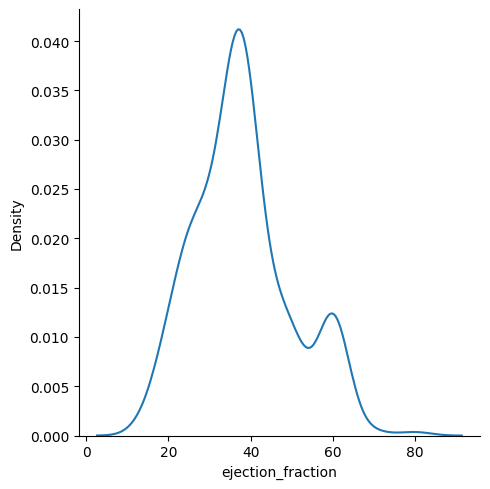

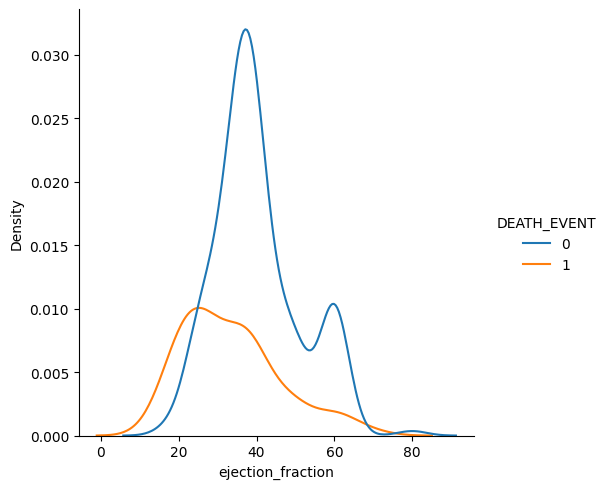

In [ ]:
sns.displot(df, x='ejection_fraction',kind='kde')
sns.displot(df, x='ejection_fraction',kind='kde', hue='DEATH_EVENT')

**For Platelets:**

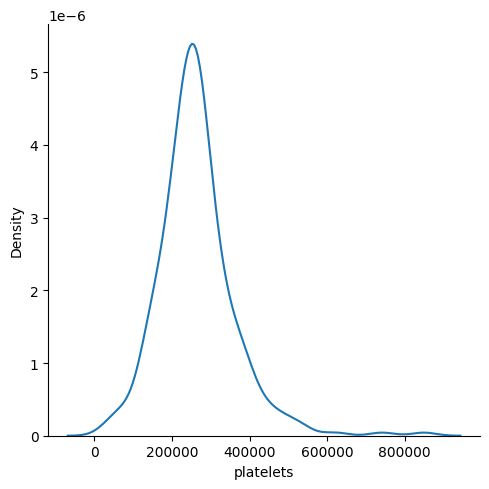

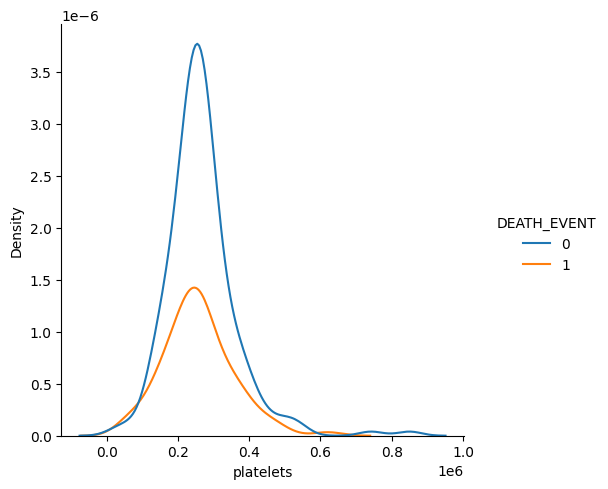

In [ ]:
sns.displot(df, x='platelets',kind='kde')
sns.displot(df, x='platelets',kind='kde', hue='DEATH_EVENT')

**For Serum Creatinine:**

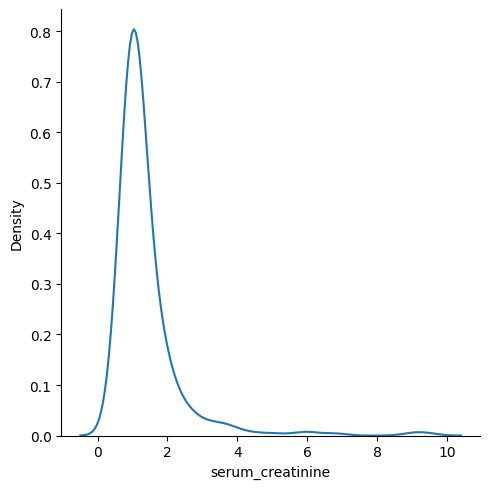

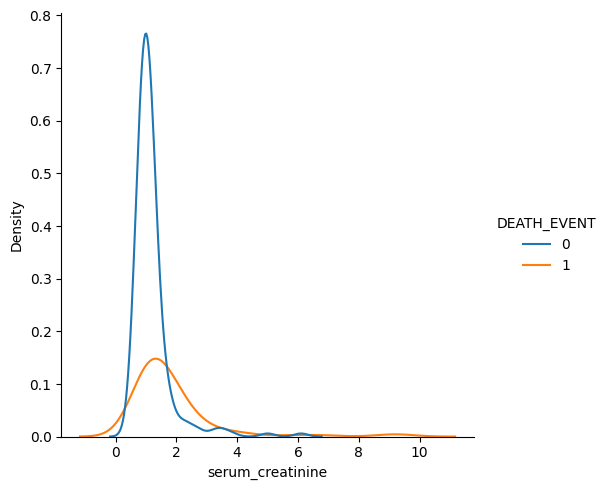

In [ ]:
sns.displot(df, x='serum_creatinine',kind='kde')
sns.displot(df, x='serum_creatinine',kind='kde', hue='DEATH_EVENT')

**For Serum Sodium:**

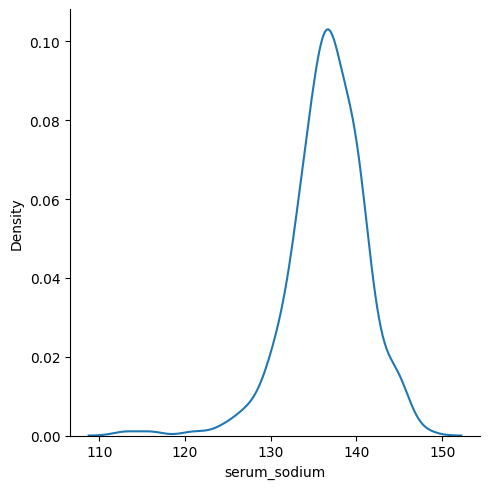

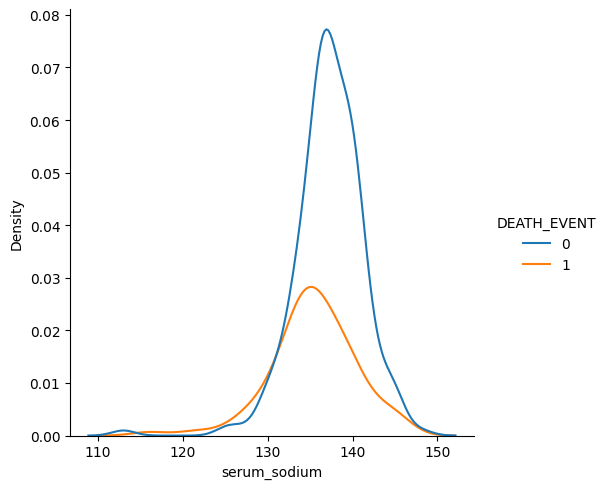

In [ ]:
sns.displot(df, x='serum_sodium',kind='kde')
sns.displot(df, x='serum_sodium',kind='kde', hue='DEATH_EVENT')

**For Time:**

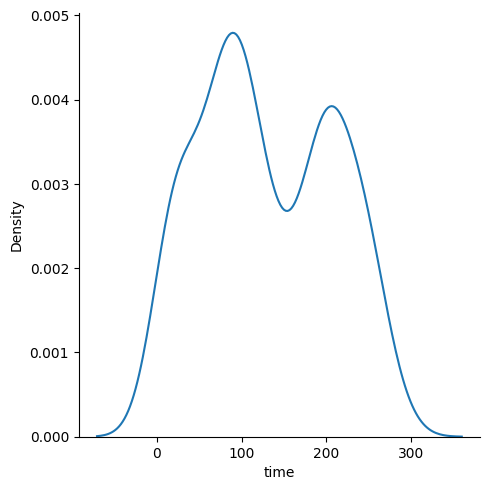

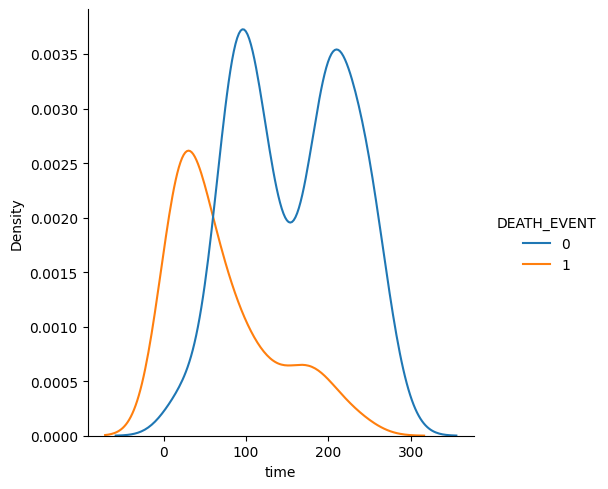

In [ ]:
sns.displot(df, x='time',kind='kde')
sns.displot(df, x='time',kind='kde', hue='DEATH_EVENT')

##**Visuallize Correlation between the independent fetures**
Visuallize the correlation between independent fetures using heatmap.

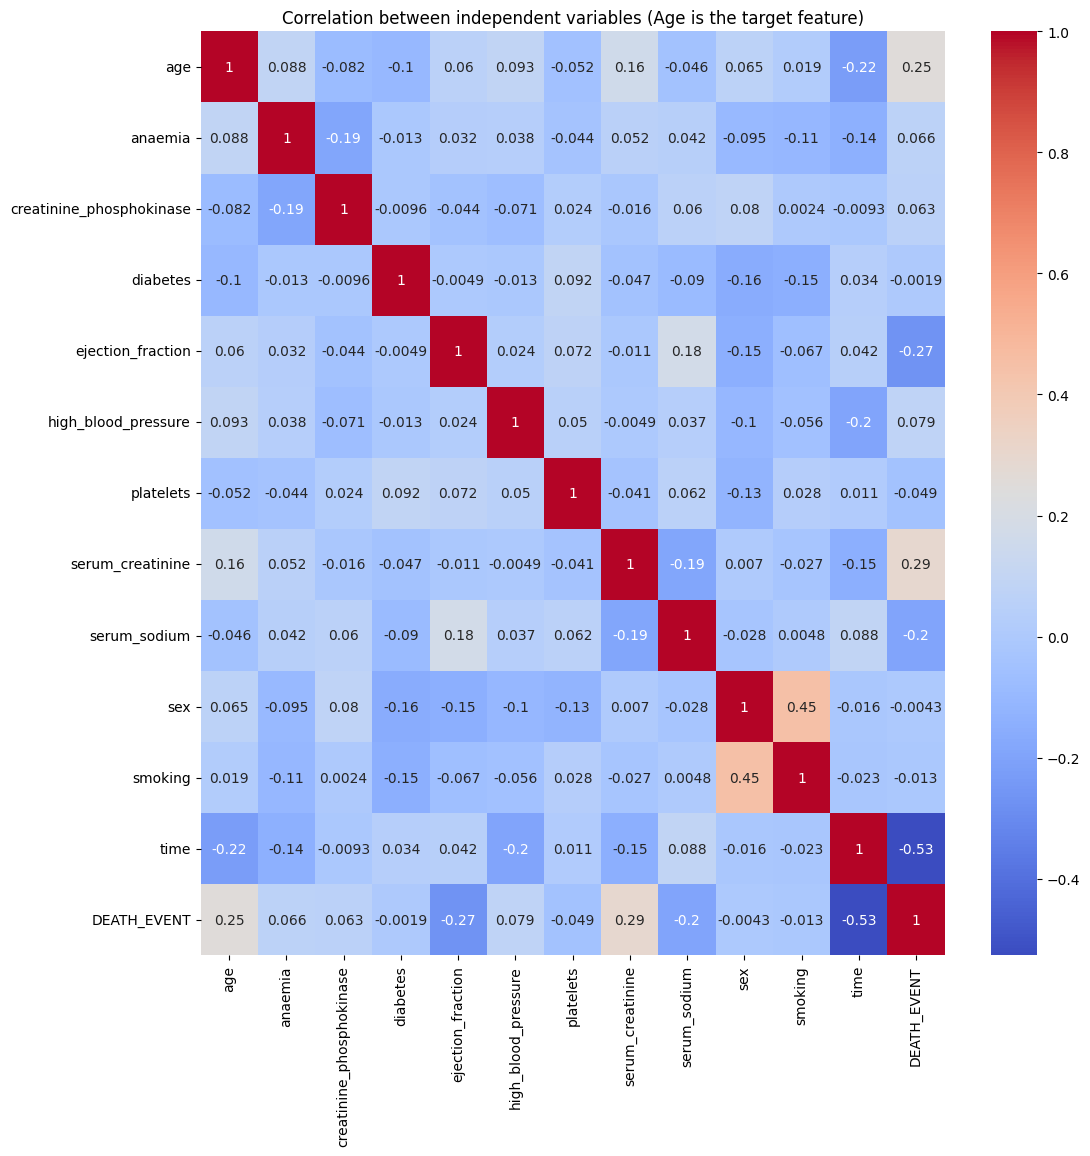

In [ ]:
independent = df
plt.figure(figsize=(12,12))
sns.heatmap(independent.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between independent variables (Age is the target feature)")
plt.show()



**Interpretation of Heatmap**  
From the heatmap above we can conclude the following:

**1. Overall correlations betwen fetures:** Most of independent fetures have a weak correlation with each other since the values of correlation coeffeicents are close to zero.  

**2. Sex and Smoking**: There is a moderate positive correlation between smoking and sex (+0.45), since 1 represents males in the dataset (From the dataset documintation), so this indicates that males are more likely to smoke than females.  

**3. Time (follow-up period) and Death event:** There is a moderate negative correlation between time (follow-up period) and death event (-0.53), that means if the follow-up increase then the death events decrease.

**4. Correlations with age:** Age shows only weak relation with all other independent variables, this means that no single feature strongly predict the age. This will reflect on the regression model performance later.

In general, the heatmap shows that there is no strong correlations between independent features, just one positive moderate correlation between sex and smoking, and negative moderate correlation between time and deth event, others are weak.

##**Visuallize Correlation between the dependent fetures and independent features**


Death event is the dependant variable:




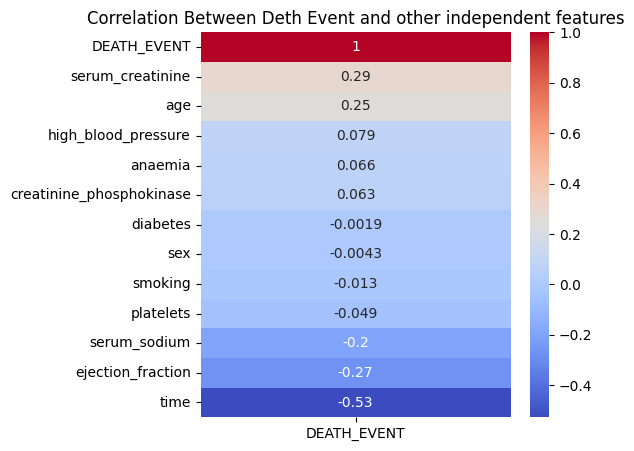

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr()[['DEATH_EVENT']].sort_values(by='DEATH_EVENT',ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation Between Deth Event and other independent features")
plt.show()

**Interpretation of Heatmap**  
From the heatmap above we can conclude the following:  
1. The most related feature  with the Death Event is time (follow-up time), with a moderate negative relation, since the correlation coeffeicent value = -0.53, so if the follow up time increase then the death occuerd decrease, and this is normal result beacause the patients who die usually have shorter follow-up times.
2. There is low positive correlation between death event and serum creatinine, since the correlation coeffeicent value = 0.29, also there is positive relation with age and the correlation coeffeicent value = 0.25, medically, higher creatinine levels related with poorer kidney work.
3. There are low negative correlations between death event and ejection fraction and between death event and serum sodium, since the correlation coeffeicent value with ejection fraction = -0.27 and the correlation coeffeicent value with serum sodium = -0.2.
4. Another features have a very low correlation with death event.

##**Data Split:**

In [ ]:
X_train, X_test = train_test_split(df, train_size = 0.8, random_state = 1)
print(X_train.shape)
print(X_test.shape)

(239, 13)
(60, 13)


##**Predict The Age:**


###**Feature Scalling:**

We will use Standardisation (Z-Score Normalization) to scale the features, this method normalises data and avoids outliers issue.  
**Standard Scaler** is scaler in sklearn library in python represents Z-Score Normalization, so i will use it to scale the numarical continuos features without target feature (in this case target is age):

In [ ]:
# Extract target feature (age here) from testing and training sets
y_train, y_test = X_train['age'], X_test['age']
X_train_age = X_train.drop(['age'] , axis=1)
X_test_age = X_test.drop(['age'] , axis=1)
X_train_age.info()
print(f"\n------------------------\n")
X_test_age.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 161 to 37
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   anaemia                   239 non-null    int64  
 1   creatinine_phosphokinase  239 non-null    int64  
 2   diabetes                  239 non-null    int64  
 3   ejection_fraction         239 non-null    int64  
 4   high_blood_pressure       239 non-null    int64  
 5   platelets                 239 non-null    float64
 6   serum_creatinine          239 non-null    float64
 7   serum_sodium              239 non-null    int64  
 8   sex                       239 non-null    int64  
 9   smoking                   239 non-null    int64  
 10  time                      239 non-null    int64  
 11  DEATH_EVENT               239 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 24.3 KB

------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 60 en

In [ ]:
# Display info about target feature (age)
y_train.info()
print(f"\n------------------------\n")
y_test.info()

<class 'pandas.core.series.Series'>
Index: 239 entries, 161 to 37
Series name: age
Non-Null Count  Dtype  
--------------  -----  
239 non-null    float64
dtypes: float64(1)
memory usage: 3.7 KB

------------------------

<class 'pandas.core.series.Series'>
Index: 60 entries, 173 to 139
Series name: age
Non-Null Count  Dtype  
--------------  -----  
60 non-null     float64
dtypes: float64(1)
memory usage: 960.0 bytes


In [ ]:
# Create Scaler and applay it on the continuos numriec features
scaler = StandardScaler()
scaler.fit(X_train_age)
x_transformed_train = scaler.transform(X_train_age)
x_transformed_test = scaler.transform(X_test_age)

In [ ]:
# Display some scaled data
print(f"Scaled Training data:\n{x_transformed_train[:5]}")
print(f"\nScaled Training data:\n{x_transformed_test[:5]}")

Scaled Training data:
[[ 1.11069566 -0.4576634  -0.84818893 -0.24318058 -0.72269841 -0.89319445
  -0.58084862  0.51465589  0.72941845  1.52297224 -0.10575054 -0.72269841]
 [-0.90033664 -0.51894319 -0.84818893  0.17737049 -0.72269841 -0.57954879
  -0.39670905  0.29500811  0.72941845 -0.65661079  1.33189826 -0.72269841]
 [ 1.11069566  0.39546617  1.17898261 -0.24318058 -0.72269841  0.15589621
  -0.30463927 -0.58358301  0.72941845 -0.65661079  0.86979686 -0.72269841]
 [ 1.11069566 -0.02487488 -0.84818893 -0.66373165  1.38370306 -1.40151673
  -0.48877884  1.83254257 -1.37095517 -0.65661079 -0.43949044 -0.72269841]
 [-0.90033664 -0.35712624  1.17898261  0.00915007 -0.72269841  0.78318753
   1.44468663  1.17359923 -1.37095517 -0.65661079 -1.27384019  1.38370306]]

Scaled Training data:
[[ 1.11069566 -0.47202585 -0.84818893 -1.5048338  -0.72269841 -0.73096394
  -0.58084862  0.51465589  0.72941845 -0.65661079  0.21515321 -0.72269841]
 [-0.90033664 -0.02487488  1.17898261  1.43902371 -0.7226984

###**One feature Linear Regression to predict the age:**

####**Select The feature:**

First display the correlation coeffecients of the features with age:

In [ ]:
corr = df.corr()
corr['age'].sort_values(ascending=False)

,age
age,1.000000
DEATH_EVENT,0.253729
serum_creatinine,0.159187
high_blood_pressure,0.093289
anaemia,0.088006
sex,0.065430
ejection_fraction,0.060098
smoking,0.018668
serum_sodium,-0.045966
platelets,-0.052354


From the table and heatmap the  we can conclude that DEATH_EVENT	has the strongest relation with age, with correlation coeffeicnt approximetly = 0.25 , so its the best choice to be a single feature to create linear regression model to predict age.

####**Create the model:**

In [ ]:
X_train_age1 = X_train_age[['DEATH_EVENT']]
X_test_age1 = X_test_age[['DEATH_EVENT']]
model = LinearRegression()
model.fit(X_train_age1, y_train)
model

LinearRegression()

####**Visualize the Linear Regression:**


Because there is only one feature we can visualize the Linear Regression and show how it fit the data using scatter plot (For the data) and line plot (For the model).

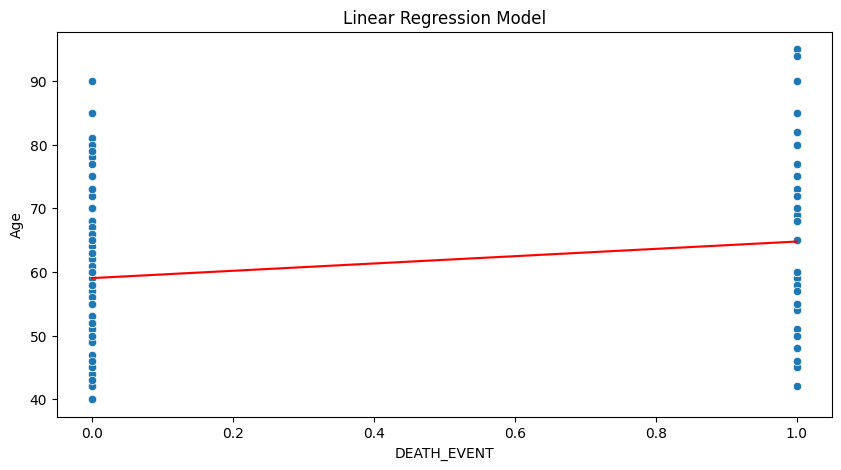

In [ ]:
plt.figure(figsize=(10,5))
X_draw = X_train_age1.squeeze()
sns.scatterplot(x=X_draw, y=y_train)
sns.lineplot(x=X_draw, y=model.predict(X_train_age1), color='red')
plt.xlabel('DEATH_EVENT')
plt.ylabel('Age')
plt.title('Linear Regression Model')
plt.show()

###**Linear Regression using all features to predict the age:**

####**Show the features and target:**

In [ ]:
print(f"Features:\n{X_train_age.columns}")
print(f"\nTarget:\n{y_train.name}")

Features:
Index(['anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction',
       'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium',
       'sex', 'smoking', 'time', 'DEATH_EVENT'],
      dtype='object')

Target:
age


####**Create the model:**

In [ ]:
model2 = LinearRegression()
model2.fit(X_train_age, y_train)
model2

LinearRegression()

###**Compare the performance using performance measures:**

We will use those performance measures:
1. Root Mean Squared Error (RMSE)
2. Mean Average Error (MAE)
3. R-Square

In [ ]:
# Predicted age values from the models
y_pred1 = model.predict(X_test_age1)
y_pred2 = model2.predict(X_test_age)

# RMSE Test
test_rsme1 = root_mean_squared_error(y_test, y_pred1)
test_rsme2 = root_mean_squared_error(y_test, y_pred2)
print(f"RSME in model with one feature: {test_rsme1}")
print(f"RSME in model with all features: {test_rsme2}")

print(f"\n------------------------\n")

# MAE Test
test_mae1 = mean_absolute_error(y_test, y_pred1)
test_mae2 = mean_absolute_error(y_test,y_pred2)
print(f"MAE in model with one feature: {test_mae1}")
print(f"MAE in model with all features: {test_mae2}")

print(f"\n------------------------\n")

# R2 Test
test_r21 = r2_score(y_test, y_pred1)
test_r22 = r2_score(y_test, y_pred2)
print(f"R2 in model with one feature: {test_r21}")
print(f"R2 in model with all features: {test_r22}")

RSME in model with one feature: 10.594357111664102
RSME in model with all features: 10.903079267644646

------------------------

MAE in model with one feature: 8.964634146341464
MAE in model with all features: 9.278983546728858

------------------------

R2 in model with one feature: 0.11420999815032296
R2 in model with all features: 0.06183355179999861


From the results we can conclude that the model with one feature (DEATH_EVENT) is more accurate and give better results than the model with all independent features, this conclusion shown by:
1. **Lower RSME (10.59 vs 10.90)**
2. **Lower MAE  ( 8.96 vs 9.28 )**
3. **Higher R2 Score ( 0.114 vs 0.062)**  

This means that add all features to the model didn't lead to improve the performance of the model, insted it may slightly decrease the performance,  because there are many features have very weak relation with the target (Age) , that will affect on the performance of the model. On contrast,  the model with the feature have the strongest relation with the target.

##**Predict The Death event:**


###**Feature Scalling:**

We will use Standardisation (Z-Score Normalization) to scale the features, this method normalises data and avoids outliers issue.  
**Standard Scaler** is scaler in sklearn library in python represents Z-Score Normalization, so i will use it to scale the numarical continuos features without target feature (in this case target is DEATH_EVENT):

In [ ]:
# Split and show the target
y_train, y_test = X_train['DEATH_EVENT'], X_test['DEATH_EVENT']
X_train_death = X_train.drop(['DEATH_EVENT'], axis=1)
X_test_death = X_test.drop(['DEATH_EVENT'], axis=1)
X_train_death.info()
print(f"\n------------------------\n")
X_test_death.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 161 to 37
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       239 non-null    float64
 1   anaemia                   239 non-null    int64  
 2   creatinine_phosphokinase  239 non-null    int64  
 3   diabetes                  239 non-null    int64  
 4   ejection_fraction         239 non-null    int64  
 5   high_blood_pressure       239 non-null    int64  
 6   platelets                 239 non-null    float64
 7   serum_creatinine          239 non-null    float64
 8   serum_sodium              239 non-null    int64  
 9   sex                       239 non-null    int64  
 10  smoking                   239 non-null    int64  
 11  time                      239 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 24.3 KB

------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 60 ent

In [ ]:
# Display info about target feature (age)
y_train.info()
print(f"\n------------------------\n")
y_test.info()

<class 'pandas.core.series.Series'>
Index: 239 entries, 161 to 37
Series name: DEATH_EVENT
Non-Null Count  Dtype
--------------  -----
239 non-null    int64
dtypes: int64(1)
memory usage: 3.7 KB

------------------------

<class 'pandas.core.series.Series'>
Index: 60 entries, 173 to 139
Series name: DEATH_EVENT
Non-Null Count  Dtype
--------------  -----
60 non-null     int64
dtypes: int64(1)
memory usage: 960.0 bytes


In [ ]:
# Create Scaler and applay it on the continuos numriec features
scaler = StandardScaler()
scaler.fit(X_train_death)
x_transformed_train = scaler.transform(X_train_death)
x_transformed_test = scaler.transform(X_test_death)

In [ ]:
# Display some scaled data
print(f"Scaled Training data:\n{x_transformed_train[:5]}")
print(f"\nScaled Training data:\n{x_transformed_test[:5]}")

Scaled Training data:
[[-1.33194278  1.11069566 -0.4576634  -0.84818893 -0.24318058 -0.72269841
  -0.89319445 -0.58084862  0.51465589  0.72941845  1.52297224 -0.10575054]
 [-0.4999137  -0.90033664 -0.51894319 -0.84818893  0.17737049 -0.72269841
  -0.57954879 -0.39670905  0.29500811  0.72941845 -0.65661079  1.33189826]
 [ 0.58172409  1.11069566  0.39546617  1.17898261 -0.24318058 -0.72269841
   0.15589621 -0.30463927 -0.58358301  0.72941845 -0.65661079  0.86979686]
 [-0.08389917  1.11069566 -0.02487488 -0.84818893 -0.66373165  1.38370306
  -1.40151673 -0.48877884  1.83254257 -1.37095517 -0.65661079 -0.43949044]
 [-0.08389917 -0.90033664 -0.35712624  1.17898261  0.00915007 -0.72269841
   0.78318753  1.44468663  1.17359923 -1.37095517 -0.65661079 -1.27384019]]

Scaled Training data:
[[-0.91592824  1.11069566 -0.47202585 -0.84818893 -1.5048338  -0.72269841
  -0.73096394 -0.58084862  0.51465589  0.72941845 -0.65661079  0.21515321]
 [-1.33194278 -0.90033664 -0.02487488  1.17898261  1.4390237

##**Logistic Regrission:**


In [ ]:
model1 = LogisticRegression(max_iter = 1000)
model1.fit(X_train_death, y_train)
model1

LogisticRegression(max_iter=1000)

##**k-Neares Neighbor :**


In [ ]:
model2 = KNeighborsClassifier()
model2.fit(X_train_death, y_train)
model2

KNeighborsClassifier()

###**Compare the performance using classification performance measures:**

We will use those performance measures:  
**1. Error Rate:** the proportion of incorrectly classified instances.  
**2. Precision:** measures the accuracy such that a class has been predicted
correctly.  
**3. Recall:** measures the proportion of positive examples that were correctly
classified.

In [ ]:
#Apply The models on the testing data since model1 is the Logistic Regression and model2 is kNN
y_pred1 = model1.predict(X_test_death)
y_pred2 = model2.predict(X_test_death)

#Find the accuracy to find the error rate
accuracy_score1 = accuracy_score(y_test, y_pred1)
accuracy_score2 = accuracy_score(y_test, y_pred2)

#Calculate the error rate from formula: 1-accuracy
error_rate1 = 1 - accuracy_score1
error_rate2 = 1 - accuracy_score2

#Find the precision score
precision_score1 = precision_score(y_test, y_pred1)
precision_score2 = precision_score(y_test, y_pred2)

#Find the recall score
recall_score1 = recall_score(y_test, y_pred1)
recall_score2 = recall_score(y_test, y_pred2)

#Create dataframe with the measures to print it as table
results = pd.DataFrame([['Logistic Regression', error_rate1, precision_score1, recall_score1],['KNN', error_rate2, precision_score2, recall_score2]],
               columns=['Model', 'Error Rate', 'Precision Score', 'Recall Score'])

#Print the results
results



,Model,Error Rate,Precision Score,Recall Score
0,Logistic Regression,0.116667,0.769231,0.714286
1,KNN,0.366667,0.100000,0.071429


From the results we can conclude that Logistic Regression is more accurate and give better results than the kNN iin this classification task, and this conclusion shown by:
1. **Lower ErrorRate (0.117 vs 0.367)**  
  That means in general, Logistic Regression more accurate in predict the correct class.
2. **Higher Precision  ( 0.770 vs 0.100 )**  
That means Logistic Regression is more accurate in predict the positive class  than kNN, and false positve is less in Logistic Regression.

3. **Higher Recall ( 0.714 vs 0.071)**  
 That means Logistic Regression is more accurate in the positive class prediction than kNN.

This means that Logistic Regression did the classification better than kNN, due to the weaknes and linearity in the relations between the target class and the most of other features, since Logistic Regression is more suitable than kNN for data like this. In Addition, kNN suitble more on the data had clear clustering and there is clear distinction among the groups, so beacuase the present dataset loss those advantages, the performance of this alogrithm will be weak.

###**Conclusion:**

In Conclusion, it's now clear that in the datasets with weak relationships between its variables the performance of regression models like Linear Regression will be limited, due to the loss of a clear linear relation between a target variable and other independent feature/s.  

In Addition, we can conclude that the Logistic Regression has an advantage over the kNN classification model, this means that Logistic Regression works better on data without clear relationships, while kNN works better on data with clear clustering and well seperated groups. All of these conclusions are based on performance measures like RMSE, R2 score in Regression and Recall, Precision in Classification.